# 🧠 Brain Tumor Detection — Deep Learning (CNN, MobileNetV2, ResNet50)


## 1. Setup & Imports

In [1]:
!pip install -r requirements.txt

In [2]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow version: 2.21.0
GPU available: False


## 2. Dataset Configuration & Discovery

In [3]:

DATASET_ROOT = "Dataset"   # <-- change this if your folder is elsewhere
IMG_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

assert os.path.isdir(DATASET_ROOT), (
    f"Dataset folder not found at '{DATASET_ROOT}'. "
    f"Update DATASET_ROOT to point at your Dataset/ directory."
)

modality_folders = sorted(
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
)
print(f"Found {len(modality_folders)} modality folder(s):")
for m in modality_folders:
    print(" -", m)


Found 2 modality folder(s):
 - Brain Tumor CT scan Images
 - Brain Tumor MRI images


In [4]:

records = []
for modality in modality_folders:
    modality_path = os.path.join(DATASET_ROOT, modality)
    class_folders = [
        d for d in os.listdir(modality_path)
        if os.path.isdir(os.path.join(modality_path, d))
    ]
    for class_name in class_folders:
        class_path = os.path.join(modality_path, class_name)
        label = "Tumor" if "tumor" in class_name.lower() else "Healthy"
        for fname in os.listdir(class_path):
            if fname.lower().endswith(IMG_EXTENSIONS):
                records.append({
                    "filepath": os.path.join(class_path, fname),
                    "modality": modality,
                    "class_folder": class_name,
                    "label": label,
                })

df = pd.DataFrame(records)
assert len(df) > 0, "No images found — check DATASET_ROOT and folder structure."
print(f"Total images found: {len(df)}")
print(df.groupby(["modality", "label"]).size())
df.head()


Total images found: 9618
modality                    label  
Brain Tumor CT scan Images  Healthy    2300
                            Tumor      2318
Brain Tumor MRI images      Healthy    2000
                            Tumor      3000
dtype: int64


,filepath,modality,class_folder,label
0,Dataset\Brain Tumor CT scan Images\Healthy\ct_...,Brain Tumor CT scan Images,Healthy,Healthy
1,Dataset\Brain Tumor CT scan Images\Healthy\ct_...,Brain Tumor CT scan Images,Healthy,Healthy
2,Dataset\Brain Tumor CT scan Images\Healthy\ct_...,Brain Tumor CT scan Images,Healthy,Healthy
3,Dataset\Brain Tumor CT scan Images\Healthy\ct_...,Brain Tumor CT scan Images,Healthy,Healthy
4,Dataset\Brain Tumor CT scan Images\Healthy\ct_...,Brain Tumor CT scan Images,Healthy,Healthy


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution

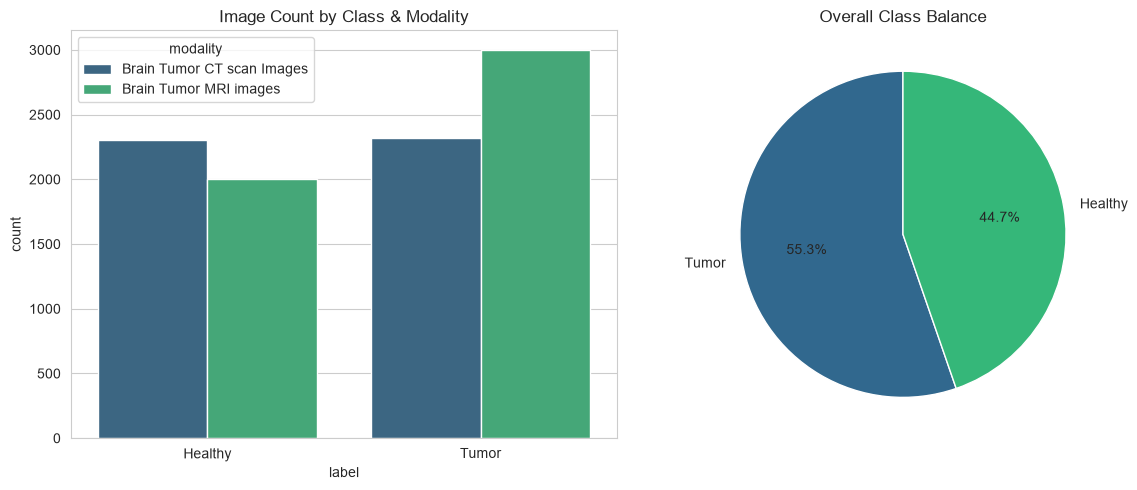

label
Tumor      55.29%
Healthy    44.71%
Name: proportion, dtype: str


In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="label", hue="modality", ax=axes[0], palette="viridis")
axes[0].set_title("Image Count by Class & Modality")

label_counts = df["label"].value_counts()
axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", len(label_counts)), startangle=90)
axes[1].set_title("Overall Class Balance")

plt.tight_layout()
plt.show()

print(df["label"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


### 3.2 Sample Images per Class

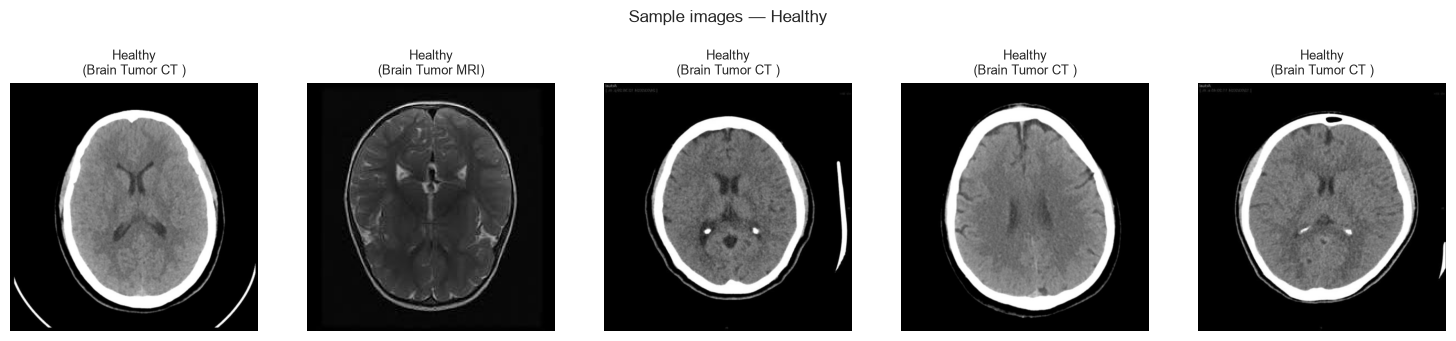

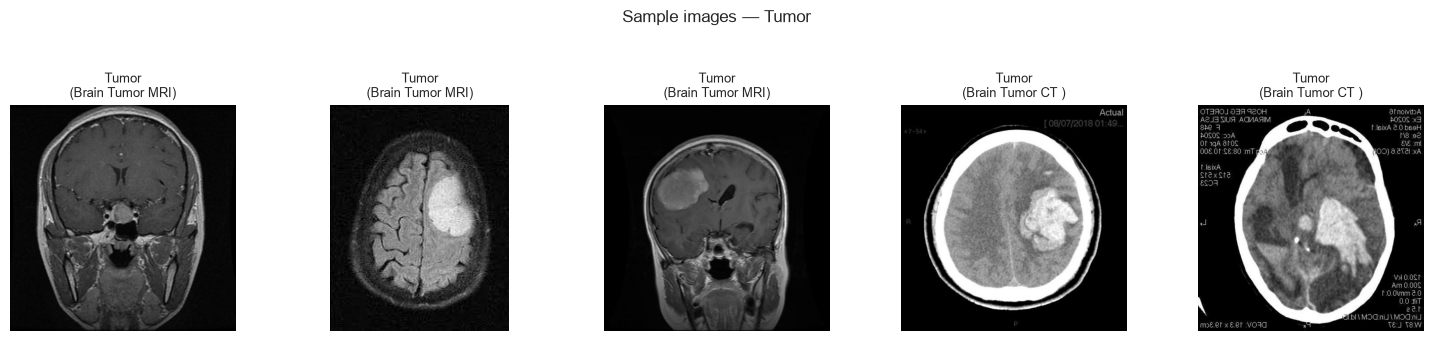

In [6]:

def show_samples(df, label, n=5):
    subset = df[df["label"] == label].sample(min(n, (df["label"] == label).sum()), random_state=RANDOM_STATE)
    fig, axes = plt.subplots(1, len(subset), figsize=(3 * len(subset), 3.2))
    if len(subset) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = cv2.cvtColor(cv2.imread(row["filepath"]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{row['label']}\n({row['modality'][:15]})", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"Sample images — {label}", y=1.05)
    plt.tight_layout()
    plt.show()

show_samples(df, "Healthy")
show_samples(df, "Tumor")


### 3.3 Image Dimensions Distribution

Reading image dimensions:   0%|          | 0/9618 [00:00<?, ?it/s]

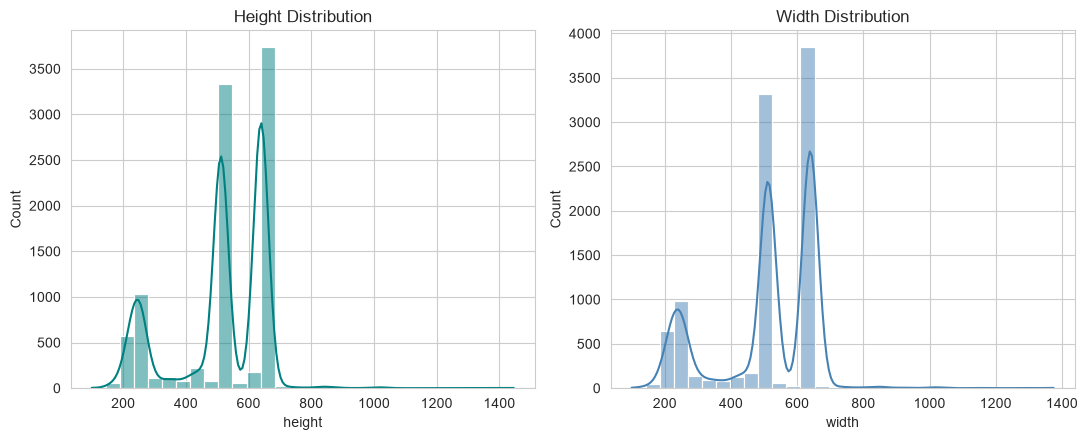

Most common resolution: (np.int64(640), np.int64(640))


In [7]:

def image_shape(path):
    img = cv2.imread(path)
    if img is None:
        return None
    h, w = img.shape[:2]
    return h, w

tqdm.pandas(desc="Reading image dimensions")
shapes = df["filepath"].progress_apply(image_shape)
shape_df = pd.DataFrame(shapes.tolist(), columns=["height", "width"])
df = pd.concat([df.reset_index(drop=True), shape_df], axis=1).dropna(subset=["height", "width"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(df["height"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Height Distribution")
sns.histplot(df["width"], bins=30, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Width Distribution")
plt.tight_layout()
plt.show()

print("Most common resolution:", df.groupby(["height", "width"]).size().idxmax())


### 3.4 Pixel Intensity Distribution per Class

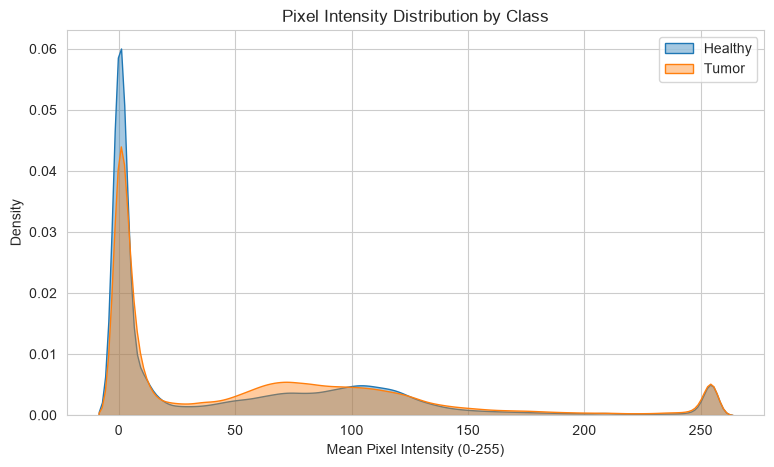

In [8]:

IMG_SIZE = (224, 224)

def load_rgb(path, size=IMG_SIZE):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size)

sample_h = df[df["label"] == "Healthy"].sample(min(150, (df["label"]=="Healthy").sum()), random_state=RANDOM_STATE)
sample_t = df[df["label"] == "Tumor"].sample(min(150, (df["label"]=="Tumor").sum()), random_state=RANDOM_STATE)

pix_h = np.concatenate([load_rgb(p).mean(axis=-1).flatten() for p in sample_h["filepath"]])
pix_t = np.concatenate([load_rgb(p).mean(axis=-1).flatten() for p in sample_t["filepath"]])

plt.figure(figsize=(9, 5))
sns.kdeplot(pix_h, label="Healthy", fill=True, alpha=0.4)
sns.kdeplot(pix_t, label="Tumor", fill=True, alpha=0.4)
plt.title("Pixel Intensity Distribution by Class")
plt.xlabel("Mean Pixel Intensity (0-255)")
plt.legend()
plt.show()


## 4. Data Pipeline — Preprocessing & Augmentation


In [9]:

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])  # Healthy=0, Tumor=1 (alphabetical)
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Healthy': np.int64(0), 'Tumor': np.int64(1)}


### 4.1 Data Augmentation Block

In [10]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


## 5. Dataset Splitting

Split into **train (70%) / validation (15%) / test (15%)**, stratified by class.


In [11]:

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label_encoded"], random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_encoded"], random_state=RANDOM_STATE
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain class balance:\n", train_df["label"].value_counts())


Train: 6732 | Val: 1443 | Test: 1443

Train class balance:
 label
Tumor      3722
Healthy    3010
Name: count, dtype: int64


In [12]:

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label, size=IMG_SIZE):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, size)
    img.set_shape([size[0], size[1], 3])
    return tf.cast(img, tf.float32), label

def make_dataset(dataframe, training=False, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].values
    labels = dataframe["label_encoded"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=RANDOM_STATE)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# Class weights (handles any class imbalance)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_encoded"]),
    y=train_df["label_encoded"]
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.1182724252491694), 1: np.float64(0.9043524986566363)}


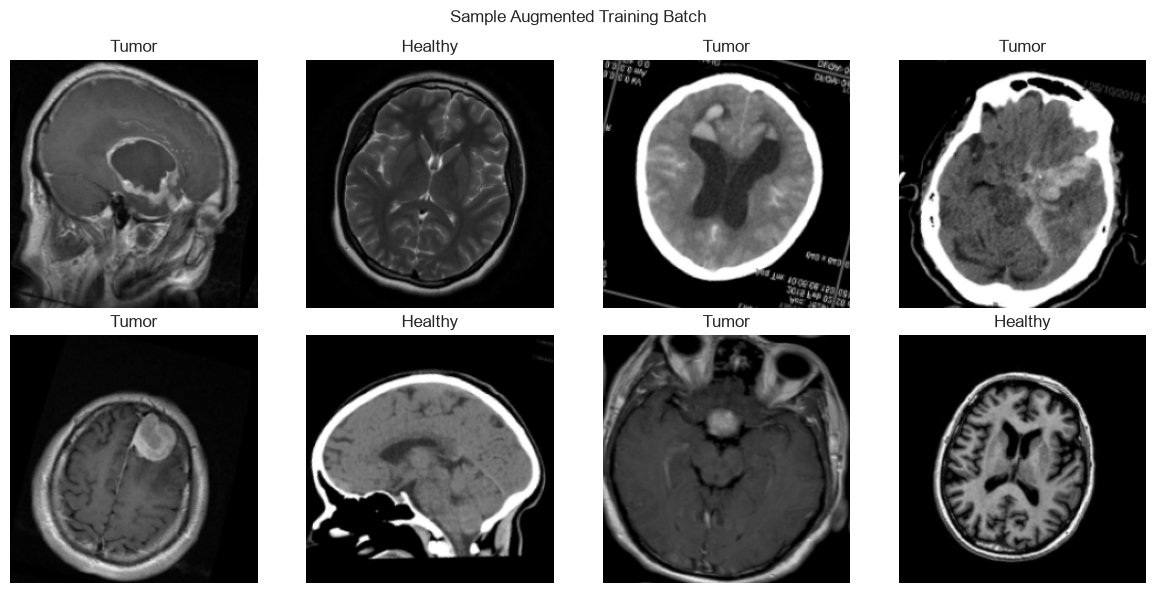

In [13]:

# Sanity check: visualize one augmented training batch
images, labels = next(iter(train_ds))
plt.figure(figsize=(12, 6))
for i in range(min(8, images.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(le.inverse_transform([int(labels[i])])[0])
    plt.axis("off")
plt.suptitle("Sample Augmented Training Batch")
plt.tight_layout()
plt.show()


## 6. Model Architectures

We build and train **3 deep learning models**:

1. **Custom CNN** — built from scratch (Conv2D + BatchNorm + MaxPool blocks)
2. **MobileNetV2** — transfer learning, ImageNet weights, frozen base + new head
3. **ResNet50** — transfer learning, ImageNet weights, frozen base + new head

All three end in a single **sigmoid** output neuron (binary: 0=Healthy, 1=Tumor)
so they stay compatible with a simple `predict_image()`-style inference function.


### 6.1 Custom CNN

In [14]:

def build_custom_cnn(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.15)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs, name="Custom_CNN")

custom_cnn = build_custom_cnn()
custom_cnn.summary()


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

### 6.2 MobileNetV2 (Transfer Learning)

In [15]:

def build_mobilenetv2(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = mobilenet_preprocess(inputs)

    base = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs, name="MobileNetV2"), base

mobilenet_model, mobilenet_base = build_mobilenetv2()
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 6.3 ResNet50 (Transfer Learning)

In [16]:

def build_resnet50(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = resnet_preprocess(inputs)

    base = ResNet50(input_shape=input_shape, include_top=False, weights="imagenet")
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs, name="ResNet50"), base

resnet_model, resnet_base = build_resnet50()
resnet_model.summary()


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │    131,136 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7. Training

Each model is compiled with `Adam` + `binary_crossentropy`, and trained with:

- `EarlyStopping` (patience on val loss, restores best weights)
- `ReduceLROnPlateau` (halves LR when val loss plateaus)
- `ModelCheckpoint` (keeps the best epoch on disk)
- `class_weight` to correct for any class imbalance

> Adjust `EPOCHS` down if you're on CPU-only / limited time; the callbacks
> will stop early once validation loss stops improving either way.


In [17]:

os.makedirs("checkpoints", exist_ok=True)
EPOCHS = 25

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        ModelCheckpoint(
            filepath=f"checkpoints/{model_name}_best.keras",
            monitor="val_loss", save_best_only=True
        ),
    ]

def compile_and_train(model, name, train_ds, val_ds, epochs=EPOCHS):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    print(f"\n{'='*70}\nTraining {name}\n{'='*70}")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(name),
        verbose=1,
    )
    return history

histories = {}
trained_models = {}

histories["Custom CNN"] = compile_and_train(custom_cnn, "custom_cnn", train_ds, val_ds)
trained_models["Custom CNN"] = custom_cnn

histories["MobileNetV2"] = compile_and_train(mobilenet_model, "mobilenetv2", train_ds, val_ds)
trained_models["MobileNetV2"] = mobilenet_model

histories["ResNet50"] = compile_and_train(resnet_model, "resnet50", train_ds, val_ds)
trained_models["ResNet50"] = resnet_model

print("\nAll 3 models trained.")



Training custom_cnn
Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 570s 3s/step - accuracy: 0.7357 - auc: 0.8070 - loss: 0.5363 - val_accuracy: 0.5530 - val_auc: 0.5816 - val_loss: 0.7395 - learning_rate: 1.0000e-04
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 617s 3s/step - accuracy: 0.8262 - auc: 0.8990 - loss: 0.4056 - val_accuracy: 0.5482 - val_auc: 0.6625 - val_loss: 1.4789 - learning_rate: 1.0000e-04
Epoch 3/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 684s 3s/step - accuracy: 0.8550 - auc: 0.9259 - loss: 0.3462 - val_accuracy: 0.5634 - val_auc: 0.8823 - val_loss: 1.4596 - learning_rate: 1.0000e-04
Epoch 4/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 582s 3s/step - accuracy: 0.8727 - auc: 0.9437 - loss: 0.3040 - val_accuracy: 0.8129 - val_auc: 0.9035 - val_loss: 0.4742 - learning_rate: 1.0000e-04
Epoch 5/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.8898 - auc: 0.9543 - loss: 0.2724 - val_accuracy: 0.8295 - val_auc: 0.9122 - val_loss: 0.4697 - learning_rate: 1.0000e-04
Epoch 6/25
211/211 ━━━━━━━━━━━━━━━

### Optional: Fine-tuning the transfer-learning models

For extra accuracy, you can unfreeze the top layers of MobileNetV2/ResNet50
after initial training and continue with a very low learning rate:

```python
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=10,
                     class_weight=class_weight_dict, callbacks=get_callbacks("mobilenetv2_finetuned"))
```

Skipped by default here to keep training time reasonable — enable if you have
a GPU and want to squeeze out extra performance.


### 7.1 Training Curves

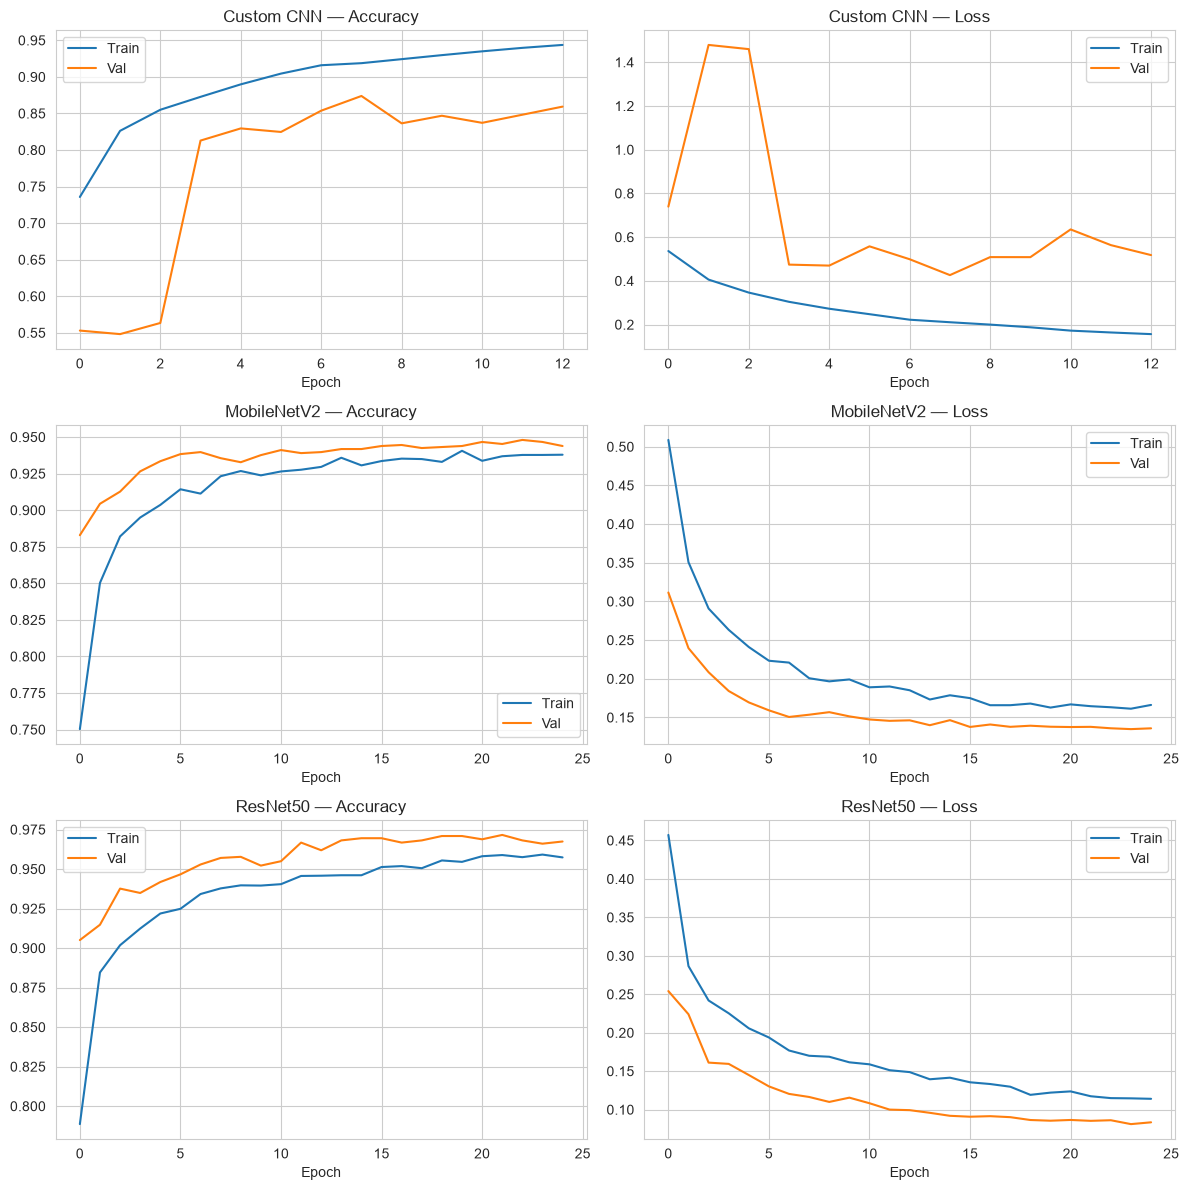

In [18]:

fig, axes = plt.subplots(len(histories), 2, figsize=(12, 4 * len(histories)))

for i, (name, hist) in enumerate(histories.items()):
    axes[i, 0].plot(hist.history["accuracy"], label="Train")
    axes[i, 0].plot(hist.history["val_accuracy"], label="Val")
    axes[i, 0].set_title(f"{name} — Accuracy")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history["loss"], label="Train")
    axes[i, 1].plot(hist.history["val_loss"], label="Val")
    axes[i, 1].set_title(f"{name} — Loss")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


## 8. Model Evaluation (on held-out Test Set)

For each model: accuracy, precision, recall, F1, AUC, confusion matrix, and ROC curve.


In [19]:

def get_test_labels(test_ds):
    return np.concatenate([y.numpy() for _, y in test_ds])

y_test = get_test_labels(test_ds)

def evaluate_model(name, model, test_ds, y_test):
    y_proba = model.predict(test_ds, verbose=0).flatten()
    y_pred = (y_proba >= 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": auc(fpr, tpr),
    }
    return metrics, y_pred, y_proba

results = []
predictions = {}

for name, model in trained_models.items():
    metrics, y_pred, y_proba = evaluate_model(name, model, test_ds, y_test)
    results.append(metrics)
    predictions[name] = (y_pred, y_proba)

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df.sort_values("F1", ascending=False)


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
ResNet50,0.9660,0.9857,0.9524,0.9688,0.9929
MobileNetV2,0.9515,0.9703,0.9411,0.9555,0.9855
Custom CNN,0.8579,0.9541,0.7807,0.8587,0.9307


### 8.1 Confusion Matrices

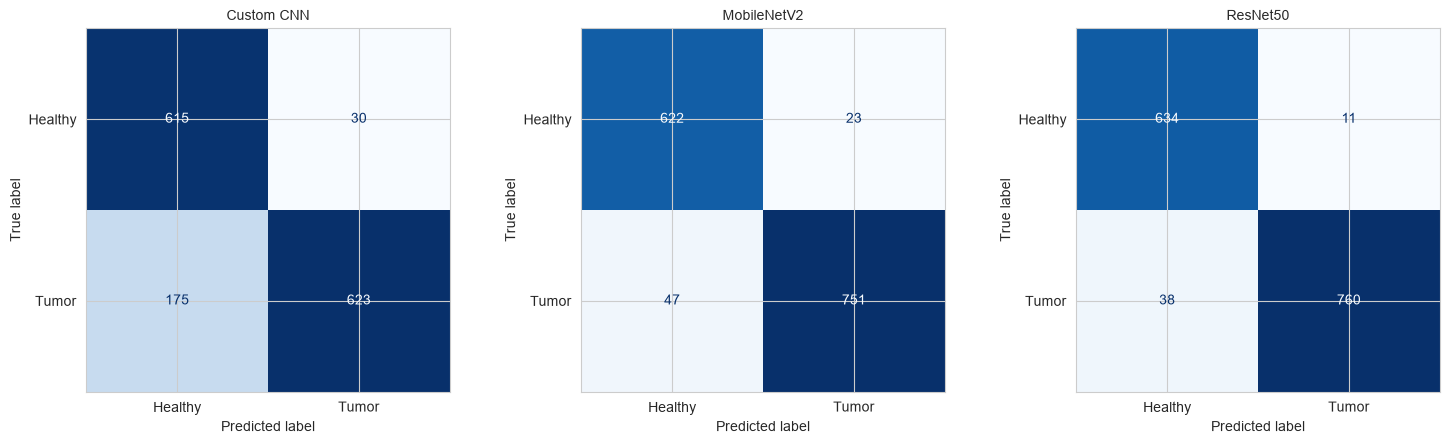

In [20]:

fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4.5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()


### 8.2 ROC Curves (all models overlaid)

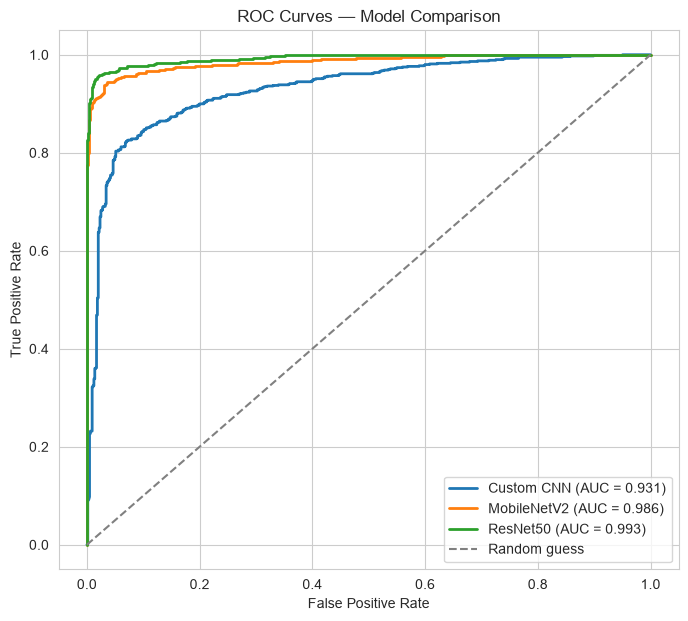

In [21]:

plt.figure(figsize=(8, 7))

for name in trained_models:
    _, y_proba = predictions[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.show()


### 8.3 Classification Reports

In [22]:

for name in trained_models:
    y_pred, _ = predictions[name]
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



Custom CNN
              precision    recall  f1-score   support

     Healthy       0.78      0.95      0.86       645
       Tumor       0.95      0.78      0.86       798

    accuracy                           0.86      1443
   macro avg       0.87      0.87      0.86      1443
weighted avg       0.88      0.86      0.86      1443


MobileNetV2
              precision    recall  f1-score   support

     Healthy       0.93      0.96      0.95       645
       Tumor       0.97      0.94      0.96       798

    accuracy                           0.95      1443
   macro avg       0.95      0.95      0.95      1443
weighted avg       0.95      0.95      0.95      1443


ResNet50
              precision    recall  f1-score   support

     Healthy       0.94      0.98      0.96       645
       Tumor       0.99      0.95      0.97       798

    accuracy                           0.97      1443
   macro avg       0.96      0.97      0.97      1443
weighted avg       0.97      0.97      

### 8.4 Metrics Comparison Chart

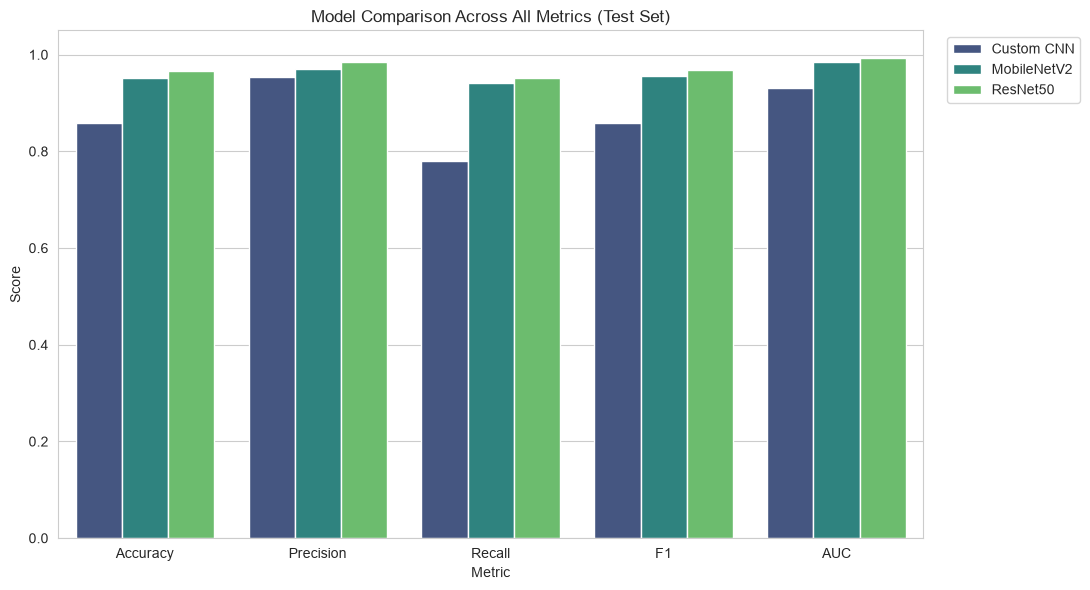

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
ResNet50,0.9660,0.9857,0.9524,0.9688,0.9929
MobileNetV2,0.9515,0.9703,0.9411,0.9555,0.9855
Custom CNN,0.8579,0.9541,0.7807,0.8587,0.9307


In [23]:

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
plot_df = results_df[metrics_to_plot].reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Model Comparison Across All Metrics (Test Set)")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

results_df.sort_values("F1", ascending=False)


## 9. Best Model Selection

Best model chosen by **F1 score** (balances precision & recall), with **AUC**
as a tiebreaker.


In [24]:

best_model_name = results_df.sort_values(["F1", "AUC"], ascending=False).index[0]
best_model = trained_models[best_model_name]

print(f"🏆 Best model: {best_model_name}")
print(results_df.loc[best_model_name])


🏆 Best model: ResNet50
Accuracy     0.9660
Precision    0.9857
Recall       0.9524
F1           0.9688
AUC          0.9929
Name: ResNet50, dtype: float64


## 10. Predictor Function

Because normalization is built **inside** each model (Rescaling /
`preprocess_input` layers), the predictor function is identical regardless of
which model you pass in — just load the raw image, resize, and predict.


In [25]:

def predict_brain_scan(image_path, model=best_model, label_encoder=le,
                        size=IMG_SIZE, show=True):
    '''
    Predict Healthy vs Tumor for a single brain scan image using a trained
    Keras model (Custom CNN / MobileNetV2 / ResNet50 — all interchangeable,
    since preprocessing is baked into each model's graph).

    Returns
    -------
    dict with 'label', 'confidence', 'probabilities'
    '''
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, size).astype("float32")
    batch = np.expand_dims(img_resized, axis=0)

    tumor_prob = float(model.predict(batch, verbose=0).flatten()[0])
    healthy_prob = 1.0 - tumor_prob
    label_idx = 1 if tumor_prob >= 0.5 else 0
    label = label_encoder.inverse_transform([label_idx])[0]
    confidence = tumor_prob if label_idx == 1 else healthy_prob

    if show:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        color = "red" if label == "Tumor" else "green"
        plt.title(f"Prediction: {label} ({confidence*100:.1f}%)", color=color, fontsize=12)
        plt.axis("off")
        plt.show()

    return {
        "label": label,
        "confidence": confidence,
        "probabilities": {"Healthy": healthy_prob, "Tumor": tumor_prob},
    }


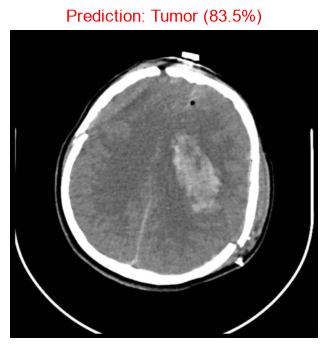

True label: Tumor  |  Predicted: Tumor  |  Confidence: 83.5%



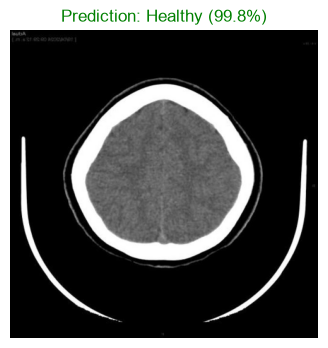

True label: Healthy  |  Predicted: Healthy  |  Confidence: 99.8%



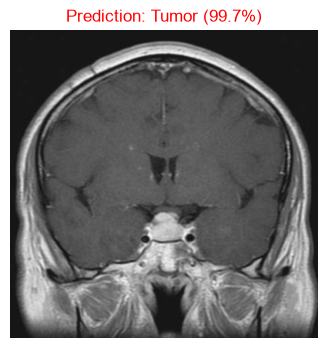

True label: Tumor  |  Predicted: Tumor  |  Confidence: 99.7%



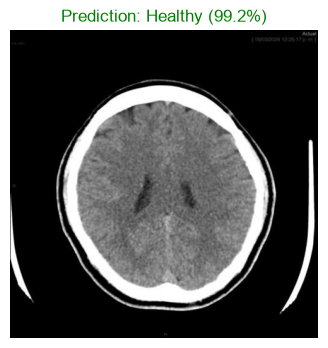

True label: Healthy  |  Predicted: Healthy  |  Confidence: 99.2%



In [26]:

# Demo: run the predictor on a few random test-set images
demo_samples = test_df.sample(min(4, len(test_df)), random_state=RANDOM_STATE)
for _, row in demo_samples.iterrows():
    result = predict_brain_scan(row["filepath"])
    print(f"True label: {row['label']}  |  Predicted: {result['label']}  |  Confidence: {result['confidence']*100:.1f}%\n")


## 11. Save Best Model

Saved in the native **`.keras`** format (Keras 3), which is the recommended
format going forward and avoids the legacy `.h5` compatibility issues that
come up when loading a Colab-trained model on a different local Python/Keras
version.


In [27]:

os.makedirs("models", exist_ok=True)

model_filename = best_model_name.lower().replace(" ", "_") + "_best.keras"
save_path = os.path.join("models", model_filename)
best_model.save(save_path)

metadata = {
    "model_name": best_model_name,
    "filename": model_filename,
    "img_size": list(IMG_SIZE),
    "class_names": list(le.classes_),   # index 0 -> Healthy, index 1 -> Tumor
    "test_metrics": results_df.loc[best_model_name].to_dict(),
}
with open(os.path.join("models", "best_model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved best model ('{best_model_name}') to: {save_path}")
print(f"File size: {os.path.getsize(save_path) / (1024*1024):.2f} MB")
print("Metadata:", json.dumps(metadata, indent=2))


Saved best model ('ResNet50') to: models\resnet50_best.keras
File size: 92.12 MB
Metadata: {
  "model_name": "ResNet50",
  "filename": "resnet50_best.keras",
  "img_size": [
    224,
    224
  ],
  "class_names": [
    "Healthy",
    "Tumor"
  ],
  "test_metrics": {
    "Accuracy": 0.966,
    "Precision": 0.9857,
    "Recall": 0.9524,
    "F1": 0.9688,
    "AUC": 0.9929
  }
}


### Loading the saved model later

```python
import tensorflow as tf
import json

model = tf.keras.models.load_model("models/<best_model_name>_best.keras")

with open("models/best_model_metadata.json") as f:
    metadata = json.load(f)

img_size = tuple(metadata["img_size"])
class_names = metadata["class_names"]

# re-use predict_brain_scan() from this notebook, or port the same logic
# into your Streamlit app's src/model_utils.py + src/preprocessing.py
```

This drops in directly to the existing Streamlit app (`app.py` +
`src/model_utils.py`) — just point `MODEL_CONFIGS` at this `.keras` filename.


## 12. Summary

- Loaded and audited the dataset across both modality folders.
- Performed EDA: class balance, sample images, resolution distributions, and
  per-class pixel intensity distributions.
- Built a unified `tf.data` pipeline (resize to 224×224, augmentation on
  train only) with per-model normalization baked into each architecture.
- Split data 70/15/15 (train/val/test), stratified, with computed class weights.
- Trained and compared **3 deep learning models**: Custom CNN, MobileNetV2
  (transfer learning), ResNet50 (transfer learning) — each with EarlyStopping,
  LR scheduling, and checkpointing.
- Evaluated with training curves, confusion matrices, ROC/AUC curves, and a
  full metrics comparison table.
- Selected the best model by F1 (AUC tiebreaker) and wrapped it in a reusable
  `predict_brain_scan()` function that works identically across all 3 models.
- Saved the best model in native `.keras` format + metadata JSON, ready to
  drop into the existing Streamlit app.

**Next steps (optional):** unfreeze + fine-tune the transfer-learning models'
top layers for extra accuracy, try `EfficientNetB0`/`DenseNet121`, or add
Grad-CAM visualizations to see *where* the model is looking for tumors.
